# MaIA Animal Detection - Data Validation & Exploratory Analysis

## Notebook Overview

This notebook handles:
1. **Environment Setup**: Install dependencies for Google Colab
2. **Data Loading**: Load existing COCO format annotations from GCS
3. **Exploratory Data Analysis (EDA)**: Analyze dataset statistics
4. **Data Validation**: Verify annotation integrity
5. **Class Distribution**: Analyze species distribution and object sizes

## Objectives
- **Primary**: Detect and count animals in dense herds
- **Secondary**: Classify species (Alcelaphinae, Buffalo, Elephant, Kob, Warthog, Waterbuck)

## Challenges Addressed
- Occlusions in dense herds
- Complex backgrounds
- Scale variations
- Class imbalance

## Note
The dataset already contains COCO-format annotations. This notebook validates and analyzes them.

In [1]:
from google.colab import auth
auth.authenticate_user()
print("User authenticated")

User authenticated


---
## 1. Environment Setup

Install all required packages for Google Colab Pro+ environment.

In [2]:
# ============================================================================
# PACKAGE INSTALLATION
# ============================================================================
# Install dependencies compatible with Google Colab Pro+
# Using specific versions to ensure reproducibility
# ============================================================================

!pip install -q \
    pyyaml==6.0 \
    pandas==2.0.3 \
    numpy==1.24.3 \
    matplotlib==3.7.2 \
    seaborn==0.12.2 \
    opencv-python==4.8.0.76 \
    pycocotools==2.0.7 \
    tqdm==4.66.1 \
    scikit-learn==1.3.0 \
    pillow==10.0.0

print("SUCCESS: Packages installed successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
SUCCESS: Packages installed successfully


In [3]:
# ============================================================================
# IMPORT LIBRARIES
# ============================================================================

import os
import sys
import json
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from pycocotools.coco import COCO
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("SUCCESS: Libraries imported")

SUCCESS: Libraries imported


---
## 2. Data Source Setup

Configure data source (Google Cloud Storage or Google Drive).

In [4]:
# ============================================================================
# CONFIGURE DATA SOURCE
# ============================================================================
# Set USE_GCS = True to load data from Google Cloud Storage
# Set USE_GCS = False to use Google Drive
# ============================================================================

USE_GCS = True  # Change to False for Google Drive workflow

# GCS Configuration
GCS_PROJECT_ID = "glass-genius-475202-s7"
GCS_BUCKET_NAME = "maia_animal_detection"

if USE_GCS:
    print("INFO: Using Google Cloud Storage as data source")

    # Authenticate with GCS
    try:
        from google.colab import auth
        auth.authenticate_user()
        print("SUCCESS: GCS authentication complete")
    except Exception as e:
        print(f"ERROR: GCS authentication failed: {e}")
        print("Falling back to Google Drive")
        USE_GCS = False

    if USE_GCS:
        # Set GCS project
        import os
        os.environ['GCLOUD_PROJECT'] = GCS_PROJECT_ID
        !gcloud config set project {GCS_PROJECT_ID}
        print(f"SUCCESS: GCS project set to {GCS_PROJECT_ID}")
else:
    print("INFO: Using Google Drive as data source")
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("SUCCESS: Google Drive mounted")
    except:
        print("INFO: Not running in Colab, using local paths")


INFO: Using Google Cloud Storage as data source
SUCCESS: GCS authentication complete
Updated property [core/project].
SUCCESS: GCS project set to glass-genius-475202-s7


In [5]:
# ===========================================================================
# CONFIGURE PATHS
# ===========================================================================
# Paths are automatically configured based on data source (GCS or Drive)
# NOTE: general_dataset is READ-ONLY - never write to this directory
# ===========================================================================

if USE_GCS:
    # Download COCO annotations from GCS to local storage
    print("INFO: Downloading COCO annotations from GCS...")
    print(f"   Source: gs://{GCS_BUCKET_NAME}/general_dataset/groundtruth/json/big_size/")
    print(f"   Destination: /content/general_dataset/groundtruth/json/big_size/")

    # Create local directory structure
    os.makedirs("/content/general_dataset/groundtruth/json/big_size", exist_ok=True)

    # Download COCO JSON files
    !gsutil -m cp gs://{GCS_BUCKET_NAME}/general_dataset/groundtruth/json/big_size/*.json /content/general_dataset/groundtruth/json/big_size/

    print("SUCCESS: COCO annotations downloaded")

    # Set paths to local downloaded data
    DATASET_ROOT = "/content/general_dataset"

    # IMPORTANT: Use local temp directory for processing, then upload to GCS
    RESULTS_BASE = "/content/results"
    GCS_RESULTS_PATH = f"gs://{GCS_BUCKET_NAME}/results"
else:
    # Use Google Drive paths
    DRIVE_ROOT = "/content/drive/MyDrive/MaIA-AnimalDetection"
    DATASET_ROOT = os.path.join(DRIVE_ROOT, "general_dataset")
    RESULTS_BASE = DRIVE_ROOT

# Dataset paths (same structure for both GCS and Drive)
TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "train")
VAL_IMG_DIR = os.path.join(DATASET_ROOT, "val")
TEST_IMG_DIR = os.path.join(DATASET_ROOT, "test")

# COCO annotations (existing files from original dataset)
COCO_DIR = os.path.join(DATASET_ROOT, "groundtruth/json/big_size")

TRAIN_COCO = os.path.join(COCO_DIR, "train_big_size_A_B_E_K_WH_WB.json")
VAL_COCO = os.path.join(COCO_DIR, "val_big_size_A_B_E_K_WH_WB.json")
TEST_COCO = os.path.join(COCO_DIR, "test_big_size_A_B_E_K_WH_WB.json")

# Results directory (write outputs here, NOT in general_dataset)
RESULTS_DIR = os.path.join(RESULTS_BASE, "results/data_analysis")
os.makedirs(RESULTS_DIR, exist_ok=True)

print("\nSUCCESS: Paths configured")
print(f"Dataset root: {DATASET_ROOT}")
print(f"COCO annotations: {COCO_DIR}")
print(f"Local results: {RESULTS_DIR}")
if USE_GCS:
    print(f"GCS results will be saved to: {GCS_RESULTS_PATH}/notebook_01_data_analysis/")

INFO: Downloading COCO annotations from GCS...
   Source: gs://maia_animal_detection/general_dataset/groundtruth/json/big_size/
   Destination: /content/general_dataset/groundtruth/json/big_size/
Copying gs://maia_animal_detection/general_dataset/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json...
Copying gs://maia_animal_detection/general_dataset/groundtruth/json/big_size/train_big_size_A_B_E_K_WH_WB.json...
Copying gs://maia_animal_detection/general_dataset/groundtruth/json/big_size/val_big_size_A_B_E_K_WH_WB.json...
- [3/3 files][  1.5 MiB/  1.5 MiB] 100% Done                                    
Operation completed over 3 objects/1.5 MiB.                                      
SUCCESS: COCO annotations downloaded

SUCCESS: Paths configured
Dataset root: /content/general_dataset
COCO annotations: /content/general_dataset/groundtruth/json/big_size
Local results: /content/results/results/data_analysis
GCS results will be saved to: gs://maia_animal_detection/results/notebook_01

---
## 3. Class Mapping Configuration

Define the mapping from original class IDs to species names.

In [6]:
# ============================================================================
# CLASS MAPPING - VERIFIED FROM GROUND TRUTH JSON
# ============================================================================
# Mapping verified from existing COCO JSON files in groundtruth/json/big_size/
# Class 1: Alcelaphinae (subfamily that includes Topi and hartebeests)
# Class 2: Buffalo
# Class 3: Kob
# Class 4: Warthog
# Class 5: Waterbuck
# Class 6: Elephant
# ============================================================================

CLASS_MAPPING = {
    1: "alcelaphinae",  # Subfamily including Topi
    2: "buffalo",
    3: "kob",
    4: "warthog",
    5: "waterbuck",
    6: "elephant"
}

# Number of classes
NUM_CLASSES = len(CLASS_MAPPING)

print(f"SUCCESS: Configured {NUM_CLASSES} animal classes:")
for class_id, class_name in CLASS_MAPPING.items():
    print(f"   {class_id}: {class_name}")

SUCCESS: Configured 6 animal classes:
   1: alcelaphinae
   2: buffalo
   3: kob
   4: warthog
   5: waterbuck
   6: elephant


---
## 4. Load and Validate COCO Annotations

Load the existing COCO format annotations and verify their integrity.

In [7]:
# ===========================================================================
# VALIDATION FUNCTIONS
# ===========================================================================

def validate_coco_file(coco_path, split_name):
    """
    Validate COCO format annotation file.

    Args:
        coco_path: Path to COCO JSON file
        split_name: Name of split (train/val/test)

    Returns:
        Dictionary with validation statistics
    """
    print(f"\n{'='*70}")
    print(f"Validating {split_name.upper()} annotations")
    print(f"{'='*70}")

    # Load COCO file
    try:
        with open(coco_path, 'r') as f:
            coco_data = json.load(f)
        print(f"SUCCESS: Loaded {coco_path}")
    except Exception as e:
        print(f"ERROR: Could not load {coco_path}: {e}")
        return None

    # Validate structure
    required_keys = ['images', 'annotations', 'categories']
    missing_keys = [k for k in required_keys if k not in coco_data]

    if missing_keys:
        print(f"ERROR: Missing required keys: {missing_keys}")
        return None

    # Extract statistics
    stats = {
        'split': split_name,
        'num_images': len(coco_data['images']),
        'num_annotations': len(coco_data['annotations']),
        'num_categories': len(coco_data['categories']),
        'avg_anns_per_image': len(coco_data['annotations']) / max(len(coco_data['images']), 1)
    }

    print(f"\nStatistics:")
    print(f"   Images: {stats['num_images']}")
    print(f"   Annotations: {stats['num_annotations']}")
    print(f"   Categories: {stats['num_categories']}")
    print(f"   Avg annotations per image: {stats['avg_anns_per_image']:.2f}")

    # Validate categories
    print(f"\nCategories:")
    for cat in coco_data['categories']:
        cat_id = cat['id']
        cat_name = cat['name']
        cat_anns = [ann for ann in coco_data['annotations'] if ann['category_id'] == cat_id]
        print(f"   {cat_id}: {cat_name:15s} - {len(cat_anns):5d} annotations")

    # Check for common issues
    issues = []

    # Check for invalid bboxes
    for ann in coco_data['annotations']:
        bbox = ann['bbox']
        if len(bbox) != 4:
            issues.append(f"Invalid bbox length for annotation {ann['id']}")
        elif bbox[2] <= 0 or bbox[3] <= 0:
            issues.append(f"Invalid bbox dimensions for annotation {ann['id']}")

    if issues:
        print(f"\nWARNINGS: Found {len(issues)} issues:")
        for issue in issues[:10]:  # Show first 10
            print(f"   - {issue}")
        if len(issues) > 10:
            print(f"   ... and {len(issues) - 10} more")
    else:
        print(f"\nVALIDATION PASSED: No issues found")

    return stats


print("SUCCESS: Validation functions defined")

SUCCESS: Validation functions defined


---
## 5. Validate All Splits

Validate train, validation, and test annotation files.

In [8]:
# ===========================================================================
# VALIDATE TRAINING SET
# ===========================================================================

print("INFO: Validating training annotations...")
train_stats = validate_coco_file(TRAIN_COCO, "train")
print()

INFO: Validating training annotations...

Validating TRAIN annotations
SUCCESS: Loaded /content/general_dataset/groundtruth/json/big_size/train_big_size_A_B_E_K_WH_WB.json

Statistics:
   Images: 928
   Annotations: 6962
   Categories: 6
   Avg annotations per image: 7.50

Categories:
   1: Alcelaphinae    -  1678 annotations
   2: Buffalo         -  1058 annotations
   3: Kob             -  1732 annotations
   4: Warthog         -   316 annotations
   5: Waterbuck       -   166 annotations
   6: Elephant        -  2012 annotations

VALIDATION PASSED: No issues found



In [9]:
# ===========================================================================
# VALIDATE VALIDATION SET
# ===========================================================================

print("INFO: Validating validation annotations...")
val_stats = validate_coco_file(VAL_COCO, "val")
print()

INFO: Validating validation annotations...

Validating VAL annotations
SUCCESS: Loaded /content/general_dataset/groundtruth/json/big_size/val_big_size_A_B_E_K_WH_WB.json

Statistics:
   Images: 111
   Annotations: 978
   Categories: 6
   Avg annotations per image: 8.81

Categories:
   1: Alcelaphinae    -   369 annotations
   2: Buffalo         -   102 annotations
   3: Kob             -   161 annotations
   4: Warthog         -    43 annotations
   5: Waterbuck       -    39 annotations
   6: Elephant        -   264 annotations

VALIDATION PASSED: No issues found



In [10]:
# ===========================================================================
# VALIDATE TEST SET
# ===========================================================================

print("INFO: Validating test annotations...")
test_stats = validate_coco_file(TEST_COCO, "test")
print()

INFO: Validating test annotations...

Validating TEST annotations
SUCCESS: Loaded /content/general_dataset/groundtruth/json/big_size/test_big_size_A_B_E_K_WH_WB.json

Statistics:
   Images: 258
   Annotations: 2299
   Categories: 6
   Avg annotations per image: 8.91

Categories:
   1: Alcelaphinae    -   675 annotations
   2: Buffalo         -   349 annotations
   3: Kob             -   477 annotations
   4: Warthog         -    74 annotations
   5: Waterbuck       -    36 annotations
   6: Elephant        -   688 annotations

VALIDATION PASSED: No issues found



---
## 6. Exploratory Data Analysis (EDA)

Analyze dataset statistics, class distribution, and bounding box sizes.

In [11]:
# ===========================================================================
# LOAD TRAINING DATA FOR ANALYSIS
# ===========================================================================

# Load COCO API for analysis
from pycocotools.coco import COCO

coco_train = COCO(TRAIN_COCO)

# Extract annotations into DataFrame for analysis
annotations_data = []
for ann_id in coco_train.getAnnIds():
    ann = coco_train.loadAnns(ann_id)[0]
    bbox = ann['bbox']  # [x, y, w, h]

    annotations_data.append({
        'annotation_id': ann['id'],
        'image_id': ann['image_id'],
        'category_id': ann['category_id'],
        'bbox_x': bbox[0],
        'bbox_y': bbox[1],
        'bbox_width': bbox[2],
        'bbox_height': bbox[3],
        'bbox_area': bbox[2] * bbox[3]
    })

df_train = pd.DataFrame(annotations_data)

# Add class names
cat_id_to_name = {cat['id']: cat['name'] for cat in coco_train.loadCats(coco_train.getCatIds())}
df_train['class_name'] = df_train['category_id'].map(cat_id_to_name)

print("\nDataset Overview:")
print(f"   Total annotations: {len(df_train)}")
print(f"   Unique images: {len(coco_train.getImgIds())}")
print(f"   Classes: {df_train['class_name'].nunique()}")
print(f"\n   Annotations per image: {len(df_train) / len(coco_train.getImgIds()):.2f}")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!

Dataset Overview:
   Total annotations: 6962
   Unique images: 928
   Classes: 6

   Annotations per image: 7.50



Class Distribution:
class_name
Alcelaphinae    1678
Buffalo         1058
Elephant        2012
Kob             1732
Warthog          316
Waterbuck        166
Name: count, dtype: int64

   Class balance ratio (max/min): 12.12


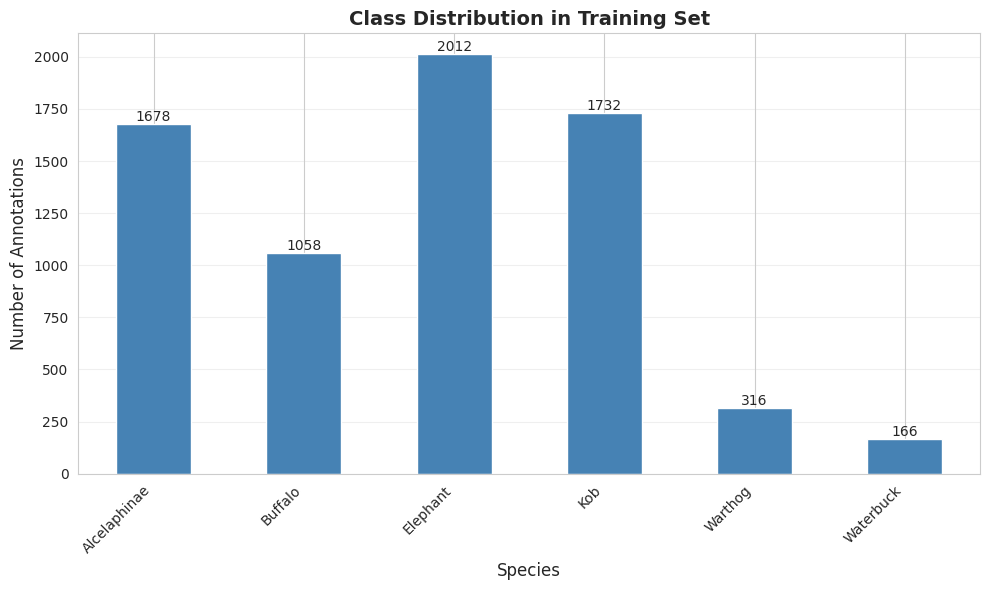


SUCCESS: Saved class_distribution.png


In [12]:
# ============================================================================
# CLASS DISTRIBUTION ANALYSIS
# ============================================================================

class_counts = df_train['class_name'].value_counts().sort_index()

print("\nClass Distribution:")
print(class_counts)
print(f"\n   Class balance ratio (max/min): {class_counts.max() / class_counts.min():.2f}")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 6))
class_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Number of Annotations', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'class_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSUCCESS: Saved class_distribution.png")


Bounding Box Statistics:
        bbox_width  bbox_height     bbox_area
count  6962.000000  6962.000000   6962.000000
mean     49.353634    48.062913   2482.573973
std      19.785552    20.027859   1656.203978
min       8.000000     6.000000     72.000000
25%      35.000000    33.000000   1344.000000
50%      47.000000    45.000000   2100.000000
75%      61.000000    60.000000   3174.000000
max     148.000000   161.000000  12648.000000


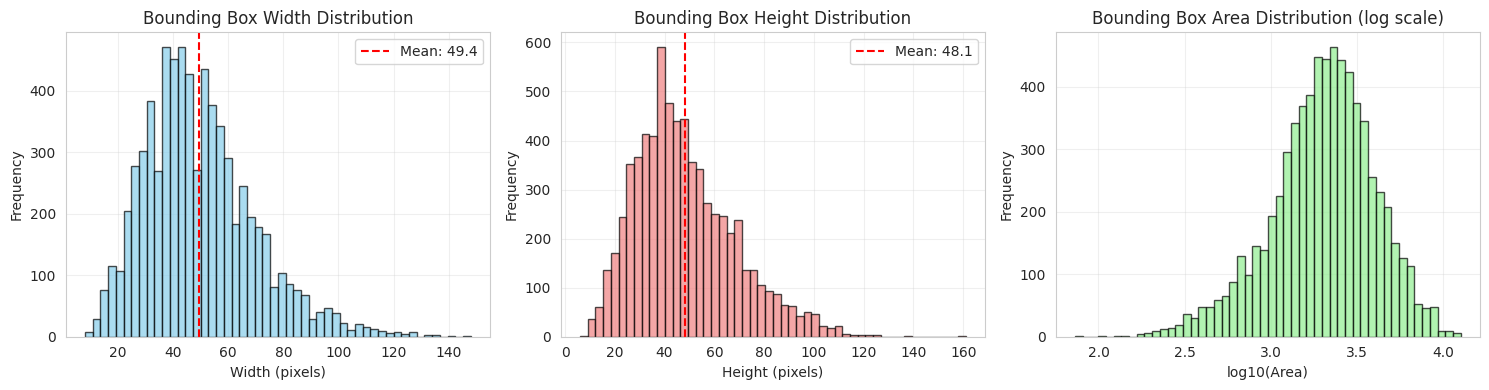


SUCCESS: Saved bbox_size_distribution.png


In [13]:
# ============================================================================
# BOUNDING BOX SIZE ANALYSIS
# ============================================================================

bbox_stats = df_train[['bbox_width', 'bbox_height', 'bbox_area']].describe()

print("\nBounding Box Statistics:")
print(bbox_stats)

# Visualize bbox size distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Width distribution
axes[0].hist(df_train['bbox_width'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_train['bbox_width'].mean(), color='red', linestyle='--', label=f'Mean: {df_train["bbox_width"].mean():.1f}')
axes[0].set_title('Bounding Box Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Height distribution
axes[1].hist(df_train['bbox_height'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(df_train['bbox_height'].mean(), color='red', linestyle='--', label=f'Mean: {df_train["bbox_height"].mean():.1f}')
axes[1].set_title('Bounding Box Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Area distribution (log scale)
axes[2].hist(np.log10(df_train['bbox_area'] + 1), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('Bounding Box Area Distribution (log scale)')
axes[2].set_xlabel('log10(Area)')
axes[2].set_ylabel('Frequency')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bbox_size_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSUCCESS: Saved bbox_size_distribution.png")

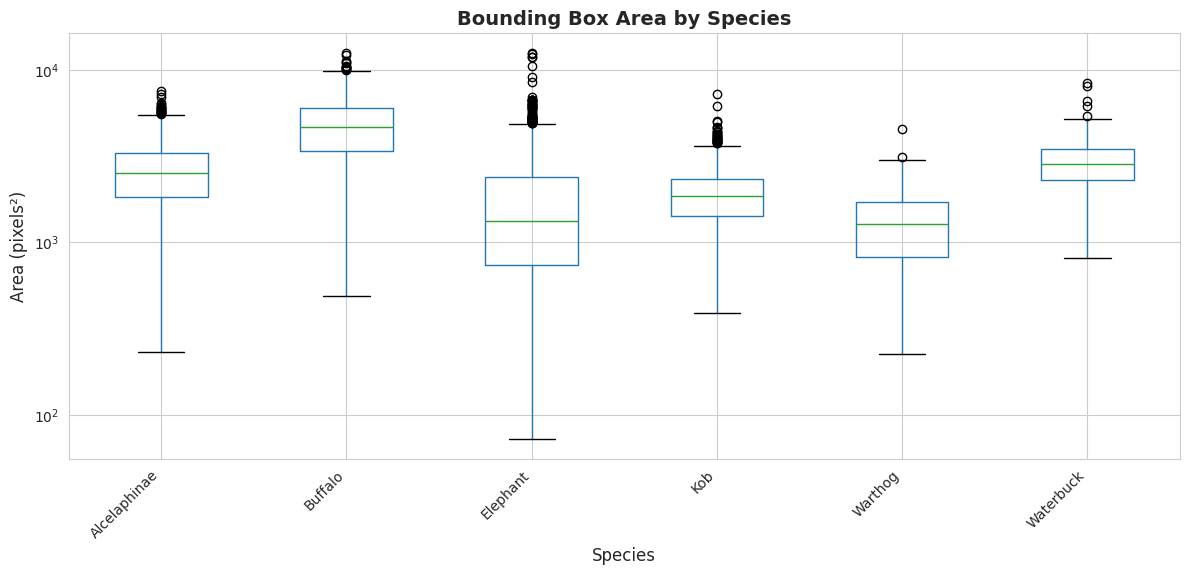


SUCCESS: Saved bbox_area_by_class.png


In [14]:
# ============================================================================
# PER-CLASS BBOX SIZE ANALYSIS
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Create boxplot for bbox area by class
df_train.boxplot(column='bbox_area', by='class_name', ax=ax)
ax.set_title('Bounding Box Area by Species', fontsize=14, fontweight='bold')
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Area (pixels²)', fontsize=12)
ax.set_yscale('log')  # Log scale for better visualization
plt.suptitle('')  # Remove default title
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bbox_area_by_class.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSUCCESS: Saved bbox_area_by_class.png")


Object Size Distribution (COCO Standard):
size_category
medium    5879
small     1058
large       25
Name: count, dtype: int64

   Small objects (<1024 px²): 1058 (15.2%)
   Medium objects (1024-9216 px²): 5879 (84.4%)
   Large objects (>9216 px²): 25 (0.4%)


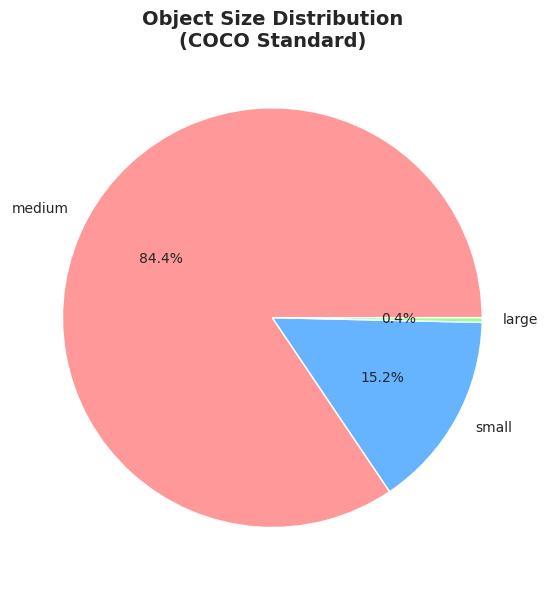


SUCCESS: Saved object_size_categories.png


In [15]:
# ============================================================================
# OBJECT SIZE CATEGORIZATION
# ============================================================================
# Categorize objects by size (useful for evaluation)
# COCO standard: small (<32²), medium (32²-96²), large (>96²)
# ============================================================================

def categorize_size(area):
    """Categorize bbox by COCO size standards."""
    if area < 32**2:
        return 'small'
    elif area < 96**2:
        return 'medium'
    else:
        return 'large'

df_train['size_category'] = df_train['bbox_area'].apply(categorize_size)

size_dist = df_train['size_category'].value_counts()

print("\nObject Size Distribution (COCO Standard):")
print(size_dist)
print(f"\n   Small objects (<1024 px²): {size_dist.get('small', 0)} ({size_dist.get('small', 0)/len(df_train)*100:.1f}%)")
print(f"   Medium objects (1024-9216 px²): {size_dist.get('medium', 0)} ({size_dist.get('medium', 0)/len(df_train)*100:.1f}%)")
print(f"   Large objects (>9216 px²): {size_dist.get('large', 0)} ({size_dist.get('large', 0)/len(df_train)*100:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
size_dist.plot(kind='pie', ax=ax, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
ax.set_ylabel('')
ax.set_title('Object Size Distribution\n(COCO Standard)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'object_size_categories.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSUCCESS: Saved object_size_categories.png")

---
## 7. Verify COCO Format with API

Verify that annotations can be loaded properly with COCO API.

In [16]:
# ============================================================================
# VALIDATE COCO FILES
# ============================================================================

print("INFO: Validating COCO files...\n")

for split_name, coco_path in [("Train", TRAIN_COCO), ("Val", VAL_COCO), ("Test", TEST_COCO)]:
    print(f"{'='*60}")
    print(f"{split_name} Set: {Path(coco_path).name}")
    print(f"{'='*60}")

    # Load with COCO API
    coco = COCO(coco_path)

    # Get statistics
    n_images = len(coco.getImgIds())
    n_annotations = len(coco.getAnnIds())
    n_categories = len(coco.getCatIds())

    print(f"   Images: {n_images}")
    print(f"   Annotations: {n_annotations}")
    print(f"   Categories: {n_categories}")
    print(f"   Avg annotations per image: {n_annotations/n_images:.2f}")

    # Show categories
    cats = coco.loadCats(coco.getCatIds())
    print(f"\n   Categories:")
    for cat in cats:
        ann_ids = coco.getAnnIds(catIds=[cat['id']])
        print(f"      {cat['id']}: {cat['name']:12s} - {len(ann_ids):5d} annotations")

    print()

print("SUCCESS: All COCO files validated successfully")

INFO: Validating COCO files...

Train Set: train_big_size_A_B_E_K_WH_WB.json
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
   Images: 928
   Annotations: 6962
   Categories: 6
   Avg annotations per image: 7.50

   Categories:
      1: Alcelaphinae -  1678 annotations
      2: Buffalo      -  1058 annotations
      3: Kob          -  1732 annotations
      4: Warthog      -   316 annotations
      5: Waterbuck    -   166 annotations
      6: Elephant     -  2012 annotations

Val Set: val_big_size_A_B_E_K_WH_WB.json
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
   Images: 111
   Annotations: 978
   Categories: 6
   Avg annotations per image: 8.81

   Categories:
      1: Alcelaphinae -   369 annotations
      2: Buffalo      -   102 annotations
      3: Kob          -   161 annotations
      4: Warthog      -    43 annotations
      5: Waterbuck    -    39 annotations
      6: Elephant     -   264 annotations

Tes

---
## 8. Visualize Sample Annotations

Visualize sample images with bounding boxes to verify data quality.

In [17]:
# ============================================================================
# VISUALIZATION FUNCTION
# ============================================================================

def visualize_annotations(coco, img_dir, num_samples=3, max_boxes=20):
    """
    Visualize random images with annotations.

    Args:
        coco: COCO object
        img_dir: Image directory
        num_samples: Number of samples to visualize
        max_boxes: Maximum number of boxes to show per image
    """
    # Color map for classes
    colors = {
        1: (255, 0, 0),      # Topi - Red
        2: (0, 255, 0),      # Buffalo - Green
        3: (0, 0, 255),      # Elephant - Blue
        4: (255, 255, 0),    # Kob - Cyan
        5: (255, 0, 255),    # Warthog - Magenta
        6: (0, 255, 255)     # Waterbuck - Yellow
    }

    # Get random images - FIX: Convert numpy int to Python int
    img_ids = coco.getImgIds()
    sample_ids = [int(x) for x in np.random.choice(img_ids, min(num_samples, len(img_ids)), replace=False)]

    for img_id in sample_ids:
        # Load image info
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            print(f"WARNING: Could not load {img_info['file_name']}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Get annotations
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        # Draw bounding boxes
        for ann in anns[:max_boxes]:
            bbox = ann['bbox']  # [x, y, w, h]
            cat_id = ann['category_id']
            cat_name = coco.loadCats(cat_id)[0]['name']

            x, y, w, h = [int(v) for v in bbox]
            color = colors.get(cat_id, (255, 255, 255))

            # Draw rectangle
            cv2.rectangle(img, (x, y), (x+w, y+h), color, 3)

            # Add label
            label = f"{cat_name}"
            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x, y-text_h-10), (x+text_w, y), color, -1)
            cv2.putText(img, label, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

        # Display
        plt.figure(figsize=(15, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{img_info['file_name']} | {len(anns)} annotations (showing {min(len(anns), max_boxes)})", fontsize=12)
        plt.tight_layout()
        plt.show()

print("SUCCESS: Visualization function defined")

SUCCESS: Visualization function defined


In [18]:
# ============================================================================
# VISUALIZE TRAINING SAMPLES
# ============================================================================

print("INFO: Visualizing training samples...\n")

coco_train = COCO(TRAIN_COCO)
visualize_annotations(coco_train, TRAIN_IMG_DIR, num_samples=3, max_boxes=15)

INFO: Visualizing training samples...

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


---
## 9. Save Dataset Statistics

Save comprehensive statistics for reference.

In [19]:
# ============================================================================
# SAVE DATASET STATISTICS TO GCS (PERSISTENT STORAGE)
# ============================================================================

# Create dataset statistics dictionary
dataset_stats = {
    "dataset_name": "MaIA Animal Detection",
    "version": "2.0",
    "num_classes": NUM_CLASSES,
    "classes": CLASS_MAPPING,
    "splits": {
        "train": train_stats,
        "val": val_stats,
        "test": test_stats
    },
    "class_distribution": class_counts.to_dict(),
    "bbox_statistics": {
        "mean_width": float(df_train['bbox_width'].mean()),
        "mean_height": float(df_train['bbox_height'].mean()),
        "mean_area": float(df_train['bbox_area'].mean()),
        "median_area": float(df_train['bbox_area'].median())
    },
    "size_categories": size_dist.to_dict()
}

# Save locally first
stats_path = os.path.join(RESULTS_DIR, 'dataset_statistics.json')
with open(stats_path, 'w') as f:
    json.dump(dataset_stats, f, indent=2)

print(f"SUCCESS: Dataset statistics saved locally: {stats_path}")

# Upload to GCS if using GCS
if USE_GCS:
    print("\n" + "="*70)
    print("UPLOADING RESULTS TO GCS (PERSISTENT STORAGE)")
    print("="*70)

    print(f"\nINFO: Uploading from {RESULTS_DIR}")
    print(f"      to gs://{GCS_BUCKET_NAME}/results/notebook_01_data_analysis/")

    # Upload all results to GCS
    !gsutil -m cp -r {RESULTS_DIR}/* gs://{GCS_BUCKET_NAME}/results/notebook_01_data_analysis/

    print("\n" + "="*70)
    print("SUCCESS: All results uploaded to GCS")
    print("="*70)
    print(f"\nResults are now permanently stored at:")
    print(f"   gs://{GCS_BUCKET_NAME}/results/notebook_01_data_analysis/")
    print(f"\nFiles uploaded:")
    print(f"   - class_distribution.png")
    print(f"   - bbox_size_distribution.png")
    print(f"   - bbox_area_by_class.png")
    print(f"   - object_size_categories.png")
    print(f"   - dataset_statistics.json")
    print(f"\nTo download results later:")
    print(f"   gsutil -m cp -r gs://{GCS_BUCKET_NAME}/results/notebook_01_data_analysis/ ./")
    print("\n" + "="*70)
else:
    print("INFO: Using Google Drive - results already saved to persistent storage")

SUCCESS: Dataset statistics saved locally: /content/results/results/data_analysis/dataset_statistics.json

UPLOADING RESULTS TO GCS (PERSISTENT STORAGE)

INFO: Uploading from /content/results/results/data_analysis
      to gs://maia_animal_detection/results/notebook_01_data_analysis/
Copying file:///content/results/results/data_analysis/bbox_area_by_class.png [Content-Type=image/png]...
Copying file:///content/results/results/data_analysis/class_distribution.png [Content-Type=image/png]...
Copying file:///content/results/results/data_analysis/bbox_size_distribution.png [Content-Type=image/png]...
Copying file:///content/results/results/data_analysis/dataset_statistics.json [Content-Type=application/json]...
Copying file:///content/results/results/data_analysis/object_size_categories.png [Content-Type=image/png]...
\ [5/5 files][579.5 KiB/579.5 KiB] 100% Done                                    
Operation completed over 5 objects/579.5 KiB.                                    

SUCCESS: A

In [20]:
# ============================================================================
# READ AND DISPLAY DATASET STATISTICS FROM GCS
# ============================================================================

from pprint import pprint

# Download statistics from GCS if using GCS
if USE_GCS:
    print("="*70)
    print("DOWNLOADING STATISTICS FROM GCS")
    print("="*70)

    # Create temp directory for downloaded stats
    temp_stats_dir = "/content/temp_stats"
    os.makedirs(temp_stats_dir, exist_ok=True)

    print(f"\nINFO: Downloading dataset_statistics.json from GCS...")
    print(f"   Source: gs://{GCS_BUCKET_NAME}/results/notebook_01_data_analysis/")

    # Download statistics file
    !gsutil cp gs://{GCS_BUCKET_NAME}/results/notebook_01_data_analysis/dataset_statistics.json {temp_stats_dir}/dataset_statistics.json

    stats_path = os.path.join(temp_stats_dir, 'dataset_statistics.json')
    print(f"   ✓ Statistics downloaded")
    print("="*70)
else:
    # Use local path
    stats_path = os.path.join(RESULTS_DIR, 'dataset_statistics.json')
    print(f"INFO: Reading statistics from local path: {stats_path}")

# Load the statistics
with open(stats_path, 'r') as f:
    stats = json.load(f)

print("\n" + "="*70)
print("DATASET STATISTICS SUMMARY")
print("="*70)

# Basic info
print(f"\nDataset: {stats['dataset_name']} (v{stats['version']})")
print(f"Number of classes: {stats['num_classes']}")

# Classes
print(f"\nClasses:")
for class_id, class_name in stats['classes'].items():
    count = stats['class_distribution'].get(class_name.capitalize(), 0)
    print(f"   {class_id}: {class_name:15s} - {count:5d} annotations")

# Splits
print(f"\nDataset Splits:")
for split_name, split_stats in stats['splits'].items():
    print(f"\n   {split_name.upper()}:")
    print(f"      Images: {split_stats['num_images']}")
    print(f"      Annotations: {split_stats['num_annotations']}")
    print(f"      Avg annotations/image: {split_stats['avg_anns_per_image']:.2f}")

# Bounding box statistics
print(f"\nBounding Box Statistics (Training Set):")
bbox_stats = stats['bbox_statistics']
print(f"   Mean width: {bbox_stats['mean_width']:.1f} px")
print(f"   Mean height: {bbox_stats['mean_height']:.1f} px")
print(f"   Mean area: {bbox_stats['mean_area']:.1f} px²")
print(f"   Median area: {bbox_stats['median_area']:.1f} px²")

# Size categories
print(f"\nObject Size Distribution (COCO Standard):")
total_objects = sum(stats['size_categories'].values())
for size_cat, count in stats['size_categories'].items():
    percentage = (count / total_objects) * 100
    print(f"   {size_cat.capitalize():8s}: {count:5d} objects ({percentage:5.1f}%)")

print("\n" + "="*70)
print("Key Insights:")
print("="*70)
print(f"✓ Total training annotations: {stats['splits']['train']['num_annotations']}")
print(f"✓ Most common species: Elephant ({stats['class_distribution']['Elephant']} annotations)")
print(f"✓ Least common species: Waterbuck ({stats['class_distribution']['Waterbuck']} annotations)")
print(f"✓ Class imbalance ratio: {stats['class_distribution']['Elephant'] / stats['class_distribution']['Waterbuck']:.1f}:1")
print(f"✓ Majority of objects are MEDIUM size ({stats['size_categories']['medium']} / {total_objects})")

print("\n" + "="*70)
print("FULL JSON (for reference):")
print("="*70)
pprint(stats, indent=2, width=100)

DOWNLOADING STATISTICS FROM GCS

INFO: Downloading dataset_statistics.json from GCS...
   Source: gs://maia_animal_detection/results/notebook_01_data_analysis/
Copying gs://maia_animal_detection/results/notebook_01_data_analysis/dataset_statistics.json...
/ [1 files][  1.1 KiB/  1.1 KiB]                                                
Operation completed over 1 objects/1.1 KiB.                                      
   ✓ Statistics downloaded

DATASET STATISTICS SUMMARY

Dataset: MaIA Animal Detection (v2.0)
Number of classes: 6

Classes:
   1: alcelaphinae    -  1678 annotations
   2: buffalo         -  1058 annotations
   3: kob             -  1732 annotations
   4: warthog         -   316 annotations
   5: waterbuck       -   166 annotations
   6: elephant        -  2012 annotations

Dataset Splits:

   TRAIN:
      Images: 928
      Annotations: 6962
      Avg annotations/image: 7.50

   VAL:
      Images: 111
      Annotations: 978
      Avg annotations/image: 8.81

   TEST:
      

---
## 10. Summary & Next Steps

### What we accomplished:
1. Validated existing COCO format annotations
2. Verified data integrity across all splits
3. Performed comprehensive EDA
4. Identified class imbalance issues
5. Analyzed object size distributions
6. Saved statistics for reference

### Key Findings:
- **Dataset size**: Check the statistics above
- **Class imbalance**: Some species are underrepresented
- **Object sizes**: Mix of small, medium, and large objects
- **Dense annotations**: Multiple animals per image (important for herd detection)

### Note:
The original dataset in gs://maia_animal_detection/general_dataset/ remains untouched (READ-ONLY).